# Emerging Technologies Assessment Notebook
### Nathan Dean - G00423489

## Package Imports

In [2]:
# Random selections.
import random

# Numerical arrays.
import numpy as np

# Permutations and combinations.
import itertools as it

# Quantum Circuits.
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Quantum simulator.
import qiskit_aer as aer

# Output display.
from IPython.display import display




## Problem 1: Generating Random Boolean Functions

### Task 

Write a function ```random_constant_balanced``` that accepts four Boolean arguements as inputs.  
Then returns a randomly chosen function from the set of constant or balanced functions.  
These randomly chosen functions being functions that accept a fixed number of Boolean inputs and return a single Boolean output.  

---


We know there will be exactly 2 contstant functions. One that for all combinations of inputs returns all 0's and one for all combinations of inputs retuns all 1's. 

For getting the balanced functions (Where the output of that function is exactly 50/50 0's & 1's) for each individual input we create an output bit. 50% 1's & 50% 0's.  

This gives us a 'truth table' for all inputs for this function. We never actually know the actual function itself, just the inputs and output.



### Truth Table for a balanced function
---

| a | b | c | d | f(a,b,c,d) |
|---|---|---|---|------------|
| 0 | 0 | 0 | 0 | 1 |
| 0 | 0 | 0 | 1 | 0 |
| 0 | 0 | 1 | 0 | 1 |
| 0 | 0 | 1 | 1 | 0 |
| 0 | 1 | 0 | 0 | 1 |
| 0 | 1 | 0 | 1 | 0 |
| 0 | 1 | 1 | 0 | 1 |
| 0 | 1 | 1 | 1 | 0 |
| 1 | 0 | 0 | 0 | 0 |
| 1 | 0 | 0 | 1 | 1 |
| 1 | 0 | 1 | 0 | 0 |
| 1 | 0 | 1 | 1 | 1 |
| 1 | 1 | 0 | 0 | 0 |
| 1 | 1 | 0 | 1 | 1 |
| 1 | 1 | 1 | 0 | 0 |
| 1 | 1 | 1 | 1 | 1 |


### Generating and returning a constant or balanced function

Given that 4 bit input means there's a finite set of inputs we can iterate through each unique input and assign an output value.  

What we assign the output bit depends on whether or not we're returning a balanced or constant function.  
To choose we use ```random.choice([True, False])```.  

If constant, we use ```random.choice([0,1])``` to choose between all ```1```'s' or all ```0```'s.  
Otherwise we set 8 bits to ```1``` & 8 bits to ```0```, then shuffle them using ```random.shuffle(outputs)``` to give us a random balanced output. 

Then creating a dictionary that uses a 4-bit tuple (our 4-bit input) as the key and the corresponding out bit value as the value.  
The ```oracle(a, b, c, d)``` function, allows us to look up a given input tuple in ```truth_table``` and returns the corresponding output.  

```oracle.truth_table = truth_table``` allows us to be able to futher inspect the ```truth_table``` if we wish. 

In [3]:
def random_constant_balanced():
    """
    Returns a random constant or balanced Boolean function.
    The returned function accepts 4 boolean inputs (a, b, c, d).
    """
    # Generate all 16 possible 4-bit inputs (using 0 and 1)
    all_inputs = list(it.product([0, 1], repeat=4))
    
    # Decide: constant or balanced
    if random.choice([True, False]):
        # Constant function: all same value
        constant_value = random.choice([0, 1])
        outputs = [constant_value] * 16
    else:
        # Balanced function: 8 ones, 8 zeros
        outputs = [1] * 8 + [0] * 8
        random.shuffle(outputs)
    
    # Create the truth table lookup
    truth_table = dict(zip(all_inputs, outputs))
    
    # Return a function that uses this truth table
    def oracle(a, b, c, d):
        return truth_table[(a, b, c, d)]
    
    # Attach the truth table to the function for inspection
    oracle.truth_table = truth_table
    
    return oracle

### Demonstration of ``` random_contant_balanced() ``` 

In [4]:
# Example usage:
random_function = random_constant_balanced()
print("Truth Table of the random function:")
for input_tuple, output in random_function.truth_table.items():
    print(f"{input_tuple} -> {output}")

Truth Table of the random function:
(0, 0, 0, 0) -> 0
(0, 0, 0, 1) -> 1
(0, 0, 1, 0) -> 1
(0, 0, 1, 1) -> 0
(0, 1, 0, 0) -> 1
(0, 1, 0, 1) -> 0
(0, 1, 1, 0) -> 0
(0, 1, 1, 1) -> 0
(1, 0, 0, 0) -> 1
(1, 0, 0, 1) -> 0
(1, 0, 1, 0) -> 1
(1, 0, 1, 1) -> 0
(1, 1, 0, 0) -> 1
(1, 1, 0, 1) -> 1
(1, 1, 1, 0) -> 0
(1, 1, 1, 1) -> 1


## Problem 2: Classical Testing for Function Type

### Task
Write a function ```determine_constant_balanced``` that takes as input a function f, as defined in Problem 1.  
The function should analyze f and return the string "constant" or "balanced" depending on whether the function is constant or balanced.

---

For the Deutsch problem (constant vs. balanced function), in classical computation, we need to call f a minimum of twice (with both possible inputs, 0 and 1) to be 100% certain whether f is constant or balanced. 

Quantum algorithms (like Deutsch's algorithm) can determine this with just supposedly one call, but classically, the maximum number is 2.

### Why do we need to call f twice to be sure?
---

If we test the function once.   
$ f(0) = 1 $  

we cannot be sure whether the function is constant or balanced, we're required to test the function once more to see whether we get the same or different output.  
$ f(1) = 0 $

Getting different output values means we have a balanced function, otherwise it's constant.

### A function to determine what type of function we have

To do this we look at the output bits in our truth table.
If all the outputs are the same then the results is a constant function. 

We check that the outputs are 50/50 '0 or 1', ensuring we're identifying a balanced function. 

If the result is anything else then our function generator is broken.


In [5]:
def determine_constant_balanced(f):
    """
    Determines if the given function f is constant or balanced.

    By inspecting the truth table of f, we can determine if it is constant (all outputs are the same) or balanced (half of the outputs are 0 and half are 1).

    Returns "constant", "balanced", or "neither".
    """
    # Create a list of outputs from the truth table
    outputs = list(f.truth_table.values())
    # Check if all outputs are the same (constant)
    if all(output == outputs[0] for output in outputs):
        return "Constant"
    # Check if there are equal numbers of 0s and 1s (balanced)
    elif outputs.count(1) == 8 and outputs.count(0) == 8:
        return "Balanced"
    # If we get here, our balanced or constant function generator is broken
    else:
        return "Generator is broken"
    
determine_constant_balanced(random_function)


'Balanced'

## Problem 3: Quantum Oracles

### Task 

Using Qiskit, create the appropriate quantum oracles for each of the possible single-Boolean-input functions used in Deutsch's algorithm. Demonstrate their use and explain how each oracle implements its corresponding function.


### What is a Quantum Oracle? 

$|x, y\rangle \xrightarrow{U_f} |x, y \oplus f(x)\rangle $  

Parameters:

- $U_f$ - Our reversible function for all inputs, the unitary matrix of function $f$
- $x$ control qubit $q0$ - This is the input $x$ to the function<br>
- $y$ target qubit ($q1$) - This qubit holds the result of the XOR operation<br>
- $\oplus$ XOR - (0 $\oplus$ 1 = 1, 1 $\oplus$ 1 = 0)<br>

Why 2 qubits for 1 classical bit operations? 
- We need the 2nd bit to enable the functions to be reversible.

Why do quantum operations need to be reversible?
- Quantum operations are represented by unitary matrices ($U_f$), which must preserve the total probability of the system. This means no information can be lost or destroyed. Because information is perfectly preserved, the operation is inherently and strictly reversible.

Cell themes, to be removed when completed


each of the possible single-Boolean-input functions used in Deutsch's algorithm  
Demonstrate their use  
explain how each oracle implements its corresponding function  

single-Boolean-input functions used in Deutsch's algorithm. Demonstrate their use and explain how each oracle implements its corresponding function  

In [6]:


def runCaseOracle(case_num):
    """Run the provided oracle (by case number) on all classical inputs and
    return the measured output of the oracle's target qubit."""
    oracle = deutsch_function_generator(case_num)  # pure oracle circuit (no H/measure)
    truth_table = {}
    for in0 in [0, 1]:
        for in1 in [0, 1]:
            # Prepare a fresh 2-qubit circuit with one classical bit for the oracle output
            test_circuit = QuantumCircuit(2, 1)
            if in0 == 1:
                test_circuit.x(0)
            if in1 == 1:
                test_circuit.x(1)
            # Apply the oracle and measure only the target qubit (qubit 1) into cbit 0
            test_circuit.compose(oracle, inplace=True)
            test_circuit.measure(1, 0)
            simulator = AerSimulator()
            compiled = qiskit.transpile(test_circuit, simulator)
            result = simulator.run(compiled, shots=1024).result()
            counts = result.get_counts()
            # Most likely outcome, as a string '0' or '1'
            output = max(counts, key=counts.get)
            truth_table[(in0, in1)] = output
    # Display truth table
    print("Input (q0,q1) → Output")
    for (a, b), out in truth_table.items():
        print(f"  ({a},{b})      →  {out}")

### The 4 one-bit operations and their respective Quantum Oracles

The ```deutsch_function_generator``` function returns one of the 4 one-bit operations as a quantum circuit.

Case 1: A quantum circuit with no gates,  always returning 0.
Case 2: A quantum circuit with a Controlled-NOT (CNOT) gate, always returning the input value.
Case 3: A quantum circuit with a CNOT and an X gate, returning NOT x value. 
Case 4: A quantum circuit with an X gate on qubit 1, always returning 1. 

We'll unpack these cases/oracles futher below.

In [7]:
def deutsch_function_generator(case: int):
    """ This function generates a quantum circuit for one of the 4 functions
    from one bit to one bit.
    
    Parameters:
        case (int): The case for which to generate the circuit. Must be 1, 2, 3, or 4.
        - Case 1: f(x) = 0(constant)
        - Case 2: f(x) = x (balanced)
        - Case 3: f(x) = 1 - x (balanced)
        - Case 4: f(x) = 1 (constant)
    
    Returns:
        QuantumCircuit: The generated quantum circuit.
    """
 
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
 
    # CHANGED: Just 2 qubits, no classical bits
    f = QuantumCircuit(2) 
    
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

#### n.b  For all the following diagrams $q0$ is our control (input) qubit and $q1$ is our target (output) qubit.



### Case 1: f(x) = 0 - Constant

Classically, this operation will always return 0 for any input. 

In a quantum circuit, because $f(x) = 0$, we are XORing the target qubit by 0. Therefore, the oracle $U_f$ acts as an identity operator (doing nothing to the qubits).

No matter what input is provided, the target qubit will remain unchanged.

Example - Input ( $q0$: 0, $q1$: 1)  

$f(x) = 0$

$|0, 1 \rangle \xrightarrow{U_f} |0, 1 \oplus f(x)\rangle$  
$|0, 1 \oplus 0\rangle$ <br>
$|0, 1 \rangle$ <br>

Case 1: f(x) = 0 (Constant)


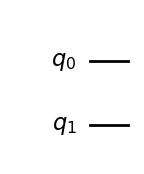

Input (q0,q1) → Output
  (0,0)      →  0
  (0,1)      →  1
  (1,0)      →  0
  (1,1)      →  1



In [8]:
print("Case 1: f(x) = 0 (Constant)")
display(deutsch_function_generator(1).draw(output='mpl'))
runCaseOracle(1)
print()

### Case 2: f(0) = 0, f(1) = 1 (Balanced) - Identity

Classically, this operation's output is the same as the input

However, in a quantum circuit, this function uses a CNOT gate to XOR the input's value onto the target qubit.

Example - Input ( $q0$: 1, $q1$: 1)

$f(x) = x$

$|1, 1 \rangle \xrightarrow{U_f} |1, 1 \oplus f(1)\rangle$  
$|1, 1 \oplus 1\rangle$ <br>
$|1, 0 \rangle$ <br>



Case 2: f(0) = 0, f(1) = 1 (Balanced)


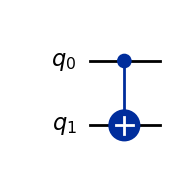

Input (q0,q1) → Output
  (0,0)      →  0
  (0,1)      →  1
  (1,0)      →  1
  (1,1)      →  0



In [9]:
# Display the circuits for each case and run the oracle tests.
print("Case 2: f(0) = 0, f(1) = 1 (Balanced)")
display(deutsch_function_generator(2).draw(output='mpl'))
runCaseOracle(2)
print()



### Case 3 :  f(0) = 1, f(1) = 0 (Balanced) - NOT

Classically, this operation's output is the exact opposite of its input.  

In a quantum circuit, the oracle must transform the target qubit to $y \oplus \text{NOT}(x)$.  
To achieve this, it uses a CNOT gate to XOR the input's value onto the target, followed by an X gate to flip the final result.  

Example - Input ( $q0$: 0, $q1$: 0)

Given $f(x) = \text{NOT}(x)$, if $x = 0$, then $f(0) = 1$.  

$|0, 0\rangle \xrightarrow{U_f} |0, 0 \oplus f(0)\rangle$  
$|0, 0 \oplus 1\rangle$  
$|0, 1\rangle$  



Case 3: f(0) = 1, f(1) = 0 (Balanced)


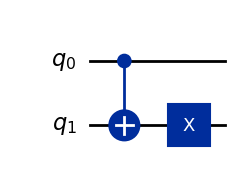

Input (q0,q1) → Output
  (0,0)      →  1
  (0,1)      →  0
  (1,0)      →  0
  (1,1)      →  1



In [10]:
print("Case 3: f(0) = 1, f(1) = 0 (Balanced)")
display(deutsch_function_generator(3).draw(output='mpl'))
runCaseOracle(3)
print()

### Case 4: f(0) = 1, f(1) = 1 (Constant) - Constant-1

Classically, this operation will always return 1 for any input.  

In a quantum circuit, because $f(x) = 1$, the oracle must evaluate the target qubit as $y \oplus 1$.  
Since the input value does not matter, the oracle simply applies an X gate (a quantum NOT gate) to the target qubit to unconditionally flip its state.  

Example - Input ($q_0$: 1, $q_1$: 0)  

Given $f(x) = 1$:

$|1, 0\rangle \xrightarrow{U_f} |1, 0 \oplus f(1)\rangle$  
$|1, 0 \oplus 1\rangle$  
$|1, 1\rangle$  

Case 4: f(0) = 1, f(1) = 1 (Constant)


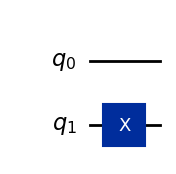

Input (q0,q1) → Output
  (0,0)      →  1
  (0,1)      →  0
  (1,0)      →  1
  (1,1)      →  0



In [11]:
print("Case 4: f(0) = 1, f(1) = 1 (Constant)")
display(deutsch_function_generator(4).draw(output='mpl'))
runCaseOracle(4)
print()

## Problem 4: Deutsch's Algorithm with Qiskit

Use Qiskit to design a quantum circuit that solves Deutsch's problem for a function with a single Boolean input.  
Implement the necessary circuit and demonstrate its use with each of the quantum oracles from Problem 3.  
Describe how the interference pattern produced by the circuit allows you to determine whether the function is constant or balanced using only one query to the oracle.

---

### Deutsch's problem

In the **Deutsch problem**, we are provided with a black-box quantum computer, or "oracle," that implements a function: $f: \{0, 1\}^n \rightarrow \{0, 1\}$.  
The function is promised to be either: 

- **Constant**: It returns the same bit ($0$ or $1$) for all possible inputs.  
- **Balanced**: It returns $1$ for exactly half of the input domain and $0$ for the other half.  

The objective is to determine which type of function the oracle represents using the minimum number of queries.  
While a classical algorithm requires $2^{n-1} + 1$ queries in the worst case to be certain, the quantum algorithm proposed by Deutsch and Jozsa (1992) can achieve this in a single query by leveraging quantum interference.

The quantum algorithm originally proposed by Deutsch (1985) and later generalized by Deutsch and Jozsa (1992) can solve this in a single query by leveraging quantum interference.

### The Classical Constraint vs. The Quantum Advantage

To understand the brilliance of Deutsch's Algorithm (and its generalization, the Deutsch-Jozsa algorithm), it helps to first look at the limitations of classical computing. 

#### The Classical Worst-Case Scenario
Imagine a Boolean function $f(x)$ that takes an $n$-bit string as input. This means there are $2^n$ possible input combinations. We are promised that this function is strictly either **constant** (returns the exact same output for every input) or **balanced** (returns 0 for exactly half of the inputs, and 1 for the other half).

If we want to determine which type of function we have with 100% certainty using a classical computer, we must evaluate the inputs one by one. 
- What if we check the first input and get a 0? We still don't know the function's type.
- What if we check exactly half of all possible inputs ($2^{n-1}$ queries) and every single one returns a 0? 

Even after $2^{n-1}$ queries, we **still** cannot be certain. The function could be constant (if the remaining half are also 0s), or it could be balanced (if the remaining half are all 1s). To be absolutely certain, we are forced to check just one more input. 

Therefore, the classical worst-case query complexity is **$2^{n-1} + 1$** queries. For a single-bit input ($n=1$), this evaluates to $2^{1-1} + 1 = 2$ queries, which we demonstrated classically in Problem 2.

#### The Quantum Solution: One Query is All it Takes
A quantum computer bypasses this classical bottleneck entirely. Instead of feeding inputs sequentially, a quantum circuit can evaluate the function's global properties using a single query. It achieves this through three core quantum mechanics principles:

1. **Superposition:** By applying Hadamard gates to our input qubits, we don't pass a single 0 or 1 into the function. Instead, we create an equal superposition of all possible input states and pass them into the quantum oracle simultaneously. 
2. **Phase Kickback:** We initialize our target (output) qubit in the $|-\rangle$ state. When the oracle evaluates the function, the result $f(x)$ isn't just written to the target qubit; it is "kicked back" as a phase shift (either $+1$ or $-1$) onto the input qubits. The phase of each state in the superposition now encodes the output of the function.
3. **Interference:** We apply a final set of Hadamard gates to the input qubits to bring them out of superposition. 
    * If the function is **constant**, the phases are identical, leading to **constructive interference**. The input qubits will deterministically collapse back to the $|0\rangle$ state.
    * If the function is **balanced**, the phases are exactly split between positive and negative, leading to **destructive interference**. The input qubits will deterministically collapse to the $|1\rangle$ state.

Because the interference pattern evaluates the *entire* phase structure at once, we only need to query the oracle **exactly one time** to find out if the function is constant or balanced, proving a massive exponential speedup over the classical approach.

### References
1.**Deutsch, D. (1985).** "Quantum Theory, the Church-Turing Principle and the Universal Quantum Computer." Proceedings of the Royal Society of London A, 400(1818): 97–117.  
2.**Deutsch, D. and Jozsa, R. (1992).** "Rapid solutions of problems by quantum computation." Proceedings of the Royal Society of London A, 439(1907): 553–558.  
3.**Cleve, R., Ekert, A., Macchiavello, C., and Mosca, M. (1998).** "Quantum algorithms revisited." Proceedings of the Royal Society of London A, 454(1969): 339–354.


--- Testing Case 1 ---


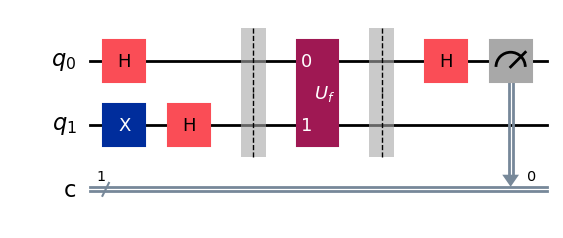

Measurement: 0 -> The function is Constant
Counts: {'0': 1024}

--- Testing Case 2 ---
Measurement: 1 -> The function is Balanced
Counts: {'1': 1024}

--- Testing Case 3 ---
Measurement: 1 -> The function is Balanced
Counts: {'1': 1024}

--- Testing Case 4 ---
Measurement: 0 -> The function is Constant
Counts: {'0': 1024}



In [12]:
def deutsch_algorithm(oracle: QuantumCircuit):
    """
    Implements Deutsch's Algorithm for a given 1-qubit oracle.
    Returns the compiled quantum circuit.
    """
    # We need 2 qubits (q0: input, q1: target) and 1 classical bit for the result
    dj_circuit = QuantumCircuit(2, 1)
    
    # 1. Initialize the target qubit (q1)
    dj_circuit.x(1)
    dj_circuit.h(1)
    
    # 2. Initialize the input qubit (q0) 
    dj_circuit.h(0)
    
    dj_circuit.barrier() 
    
    # 3. Apply the Quantum Oracle as a custom gate
    # This turns the oracle circuit into a single visual block
    oracle_gate = oracle.to_gate(label="$U_f$")
    dj_circuit.append(oracle_gate, [0, 1])
    
    dj_circuit.barrier()
    
    # 4. Apply H-gate to the input qubit to cause interference
    dj_circuit.h(0)
    
    # 5. Measure the input qubit (q0) into the classical bit (c0)
    dj_circuit.measure(0, 0)
    
    return dj_circuit
# Let's demonstrate this for all 4 cases from Problem 3
simulator = AerSimulator()

for case in range(1, 5):
    print(f"--- Testing Case {case} ---")
    
    # Get the oracle from the function you wrote in Problem 3
    oracle = deutsch_function_generator(case)
    
    # Build the full Deutsch circuit
    circuit = deutsch_algorithm(oracle)
    
    # Draw the circuit for the first case just to see what it looks like
    if case == 1:
        display(circuit.draw(output='mpl'))
        
    # Run the circuit on the simulator
    compiled_circuit = qiskit.transpile(circuit, simulator)
    result = simulator.run(compiled_circuit, shots=1024).result()
    counts = result.get_counts()
    
    # The output will be either '0' (Constant) or '1' (Balanced)
    measured_bit = list(counts.keys())[0]
    function_type = "Constant" if measured_bit == '0' else "Balanced"
    
    print(f"Measurement: {measured_bit} -> The function is {function_type}")
    print(f"Counts: {counts}\n")

### How Interference Determines the Function Type

The circuit diagram above visually demonstrates the elegant mechanics of Deutsch's Algorithm. By leveraging quantum interference, we evaluate the function's global properties in a single query. Here is the step-by-step breakdown of how the measurement determines if the function is constant or balanced:

#### 1. State Preparation
We start with two qubits: $q_0$ (our input) in state $|0\rangle$ and $q_1$ (our target) in state $|1\rangle$ (achieved via the initial X gate). We apply a Hadamard (H) gate to both. 
* $q_0$ enters the $|+\rangle$ state: $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
* $q_1$ enters the $|-\rangle$ state: $\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$

The combined state before querying the oracle is:
$$|\psi_1\rangle = \left[ \frac{|0\rangle + |1\rangle}{\sqrt{2}} \right] \left[ \frac{|0\rangle - |1\rangle}{\sqrt{2}} \right]$$

#### 2. Querying the Oracle ($U_f$) and Phase Kickback
We pass this superposition into the oracle ($U_f$). Because our target qubit $q_1$ is in the $|-\rangle$ state, evaluating the function $f(x)$ triggers a phenomenon called **phase kickback**. The output of the function isn't just flipped on the target qubit; it is kicked back as a phase shift of $(-1)^{f(x)}$ onto the input qubit $q_0$.

The state of our input qubit $q_0$ becomes:
$$|\psi_2\rangle = \frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}}$$

#### 3. Interference and Measurement
This is where the magic happens. We apply a final H gate to $q_0$ to bring it out of superposition, forcing the states to interfere with one another. 

* **If the function is Constant ($f(0) = f(1)$):**
  Both states received the exact same phase shift. They are entirely in sync. This causes **constructive interference**. The input qubit $q_0$ is essentially still in the $|+\rangle$ state (ignoring an unobservable global phase). Applying the final H gate maps $|+\rangle$ directly back to the deterministic state **$|0\rangle$**. 

* **If the function is Balanced ($f(0) \neq f(1)$):**
  The states received opposite phase shifts (one got $+1$, the other got $-1$). This creates a relative phase difference, causing **destructive interference**. The input qubit $q_0$ has been transformed into the $|-\rangle$ state. Applying the final H gate maps $|-\rangle$ directly to the deterministic state **$|1\rangle$**.

### Conclusion
By observing the classical bit after measurement, we have our answer:
* A measurement of **`0`** means the interference was constructive, so the function is **Constant**.
* A measurement of **`1`** means the interference was destructive, so the function is **Balanced**.

As shown in the output logs above, the algorithm accurately classified all four oracles using only a single run (1024 shots all yielding the same deterministic outcome).

# Problem 5: Scaling to the Deutsch–Jozsa Algorithm

## Task

Use Qiskit to create a quantum circuit that can handle the four-bit functions generated in Problem 1. 
Explain how the classical function is encoded as a quantum oracle, and demonstrate the use of your circuit on both of the constant functions and any two balanced functions of your choosing. 

Show that the circuit correctly identifies the type of each function.

### Encoding the Classical Function into a Quantum Oracle

To run the Deutsch-Jozsa algorithm on a classical 4-bit function, we must convert its truth table into a reversible quantum circuit (the Oracle $U_f$). The oracle must map the state $|x, y\rangle$ to $|x, y \oplus f(x)\rangle$.

Since we have the entire truth table from Problem 1, we can systematically build this oracle using a "Sum of Products" (or minterm) approach:
1. **Identify the 1s:** Look at the truth table and find every input string $x$ where $f(x) = 1$.
2. **Isolate the State:** For each of these inputs, we want to flip the target qubit ($y$) using a Multi-Controlled X (MCX) gate. An MCX gate only triggers when all control qubits are `1`. 
3. **Bit-Flipping:** If our target input string contains zeros (e.g., `0101`), we temporarily apply $X$ gates to the `0` positions to flip them to `1`. Then we apply the MCX gate, and finally, we uncompute the $X$ gates to restore the input to its original state.

By repeating this for every input combination that evaluates to 1, the quantum circuit perfectly mimics the classical Boolean function in a reversible quantum manner.

--- Testing Function: Constant 0 ---


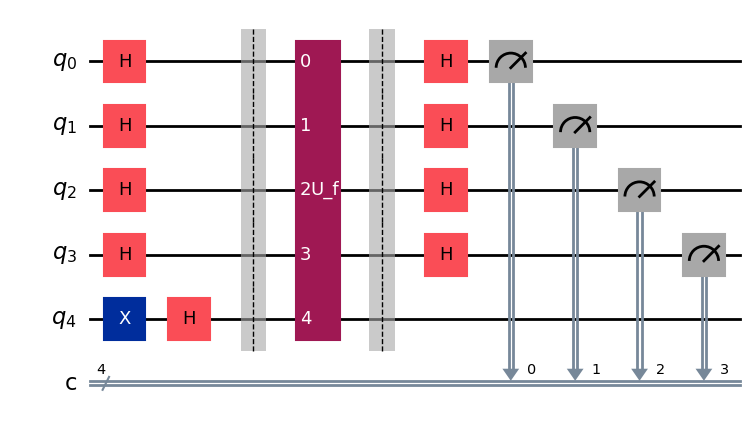

Measurement: 0000 -> The function is Constant
Counts: {'0000': 1024}

--- Testing Function: Constant 1 ---
Measurement: 0000 -> The function is Constant
Counts: {'0000': 1024}

--- Testing Function: Balanced (q0=1) ---
Measurement: 0001 -> The function is Balanced
Counts: {'0001': 1024}

--- Testing Function: Balanced (Odd Parity) ---
Measurement: 1111 -> The function is Balanced
Counts: {'1111': 1024}



In [ ]:
def build_oracle_from_truth_table(truth_table):
    """
    Encodes a 4-bit truth table into a 5-qubit quantum oracle.
    q0-q3 are the inputs, q4 is the target.
    """
    oracle = QuantumCircuit(5)
    
    for input_state, output_val in truth_table.items():
        if output_val == 1:
            # Find which qubits need to be flipped (where input is 0)
            zero_indices = [i for i, bit in enumerate(input_state) if bit == 0]
            
            # Apply X to make the control state all 1s
            if zero_indices:
                oracle.x(zero_indices)
                
            # Apply 4-controlled-X gate targeting q4
            oracle.mcx([0, 1, 2, 3], 4)
            
            # Uncompute the X gates to restore the original input state
            if zero_indices:
                oracle.x(zero_indices)
                
    # Return it as a custom black-box gate (just like Problem 4)
    return oracle.to_gate(label="U_f")
    
def deutsch_jozsa_4bit(oracle_gate):
    """
    Builds the DJ circuit for a 4-bit input oracle.
    """
    # 5 qubits (4 input, 1 target), 4 classical bits for measurement
    dj_circuit = QuantumCircuit(5, 4)
    
    # 1. Initialize target qubit (q4) to |-> for phase kickback
    dj_circuit.x(4)
    dj_circuit.h(4)
    
    # 2. Initialize input qubits (q0-q3) to |+> for superposition
    dj_circuit.h([0, 1, 2, 3])
    
    dj_circuit.barrier()
    
    # 3. Apply the Oracle
    dj_circuit.append(oracle_gate, [0, 1, 2, 3, 4])
    
    dj_circuit.barrier()
    
    # 4. Apply H-gates to input qubits for interference
    dj_circuit.h([0, 1, 2, 3])
    
    # 5. Measure the inputs
    dj_circuit.measure([0, 1, 2, 3], [0, 1, 2, 3])
    
    return dj_circuit

### Constructing the Deutsch-Jozsa Circuit

The `deutsch_jozsa_4bit` function implements the generalized algorithm for our $n=4$ bit inputs. The structure is nearly identical to the 1-bit Deutsch algorithm, just scaled up:

1. **Initialization:** We allocate 5 qubits in total (4 for the input query, 1 for the target) and 4 classical bits to read the final measurement. The target qubit is prepared in the $|-\rangle$ state by applying an $X$ gate followed by an $H$ gate.
2. **Superposition:** We apply a Hadamard gate to all 4 input qubits simultaneously. This creates an equal superposition of all 16 possible input states ($|0000\rangle$ to $|1111\rangle$), allowing us to query the entire truth table at once.
3. **Oracle Application:** We append the custom $U_f$ oracle gate (generated from our truth table) to the circuit, applying it across all 5 qubits. This triggers phase kickback based on the function's outputs.
4. **Interference:** We apply a final set of Hadamard gates to the 4 input qubits.
5. **Measurement:** We measure the 4 input qubits into our classical bits. If the function is constant, constructive interference will deterministically collapse the state back to `0000`. If it is balanced, destructive interference guarantees we will measure a state containing at least one `1` (anything other than `0000`).